In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Electrolyte solutions &mdash; Debye&ndash;H&uuml;ckel and its extensions

**Illustrations 9.10-1 and 9.10-2**, and **Figure 9.10-2**.

Section 9.10 is the one place in Chapter 9 where the independent variable is not mole
fraction. A dissolved salt breaks into ions, the ions interact through Coulomb forces
that reach much further than the forces between neutral molecules, and the solution is
already strongly nonideal at concentrations where a mixture of neutral species would
still be ideal. None of the models in Sections 9.5 and 9.6 can describe that, because
none of them knows about charge.

What makes this section different in a second way is that **the individual ion activity
coefficients cannot be measured at all.** Electroneutrality (Eq. 9.10-3) means you
cannot add cations without adding anions, so $\gamma_+$ and $\gamma_-$ never appear
apart. Only their geometric mean, the **mean ionic activity coefficient**
$\gamma_\pm$, is measurable &mdash; so that is the only thing a model here is asked to
produce.

This notebook builds the three equations of the section, checks them against the
chapter's own two data sets, and &mdash; because the section's equations had never been
checked against anything &mdash; **audits Table 9.10-1 itself**.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo import DebyeHuckel, Electrolyte, ELECTROLYTES, TABLE_9_10_1, water_parameters
from thermo.electrolytes import ILLUSTRATION_9_10_1_HCL, ILLUSTRATION_9_10_2_NACL
from thermo.charts import use_book_style
use_book_style()

True

## The three equations

$$\ln\gamma_\pm = -\alpha\,|z_+z_-|\sqrt{I}
\tag{9.10-15, the limiting law}$$

$$\ln\gamma_\pm = \frac{-\alpha\,|z_+z_-|\sqrt{I}}{1+\beta a\sqrt{I}}
\tag{9.10-17}$$

$$\ln\gamma_\pm = \frac{-\alpha\,|z_+z_-|\sqrt{I}}{1+\beta a\sqrt{I}} + \delta I
\tag{9.10-18}$$

with the **ionic strength**

$$I = \tfrac{1}{2}\sum_{i\ \rm ions} z_i^2 M_i \tag{9.10-16}$$

They are one family, not three models: each adds a term to the one before, and all
three share the same limiting slope $\alpha|z_+z_-|$ as $I\to 0$. So `DebyeHuckel`
is one class, and which equation you get depends on which parameters you give it.

**Everything here is a molality** &mdash; moles of solute per kilogram of
*solvent*, not per liter of solution. The book says outright that it will sometimes
ignore the distinction, and Figs. 9.10-1 and 9.10-2 do (9.10-1's abscissa is labeled
molarity; 9.10-2's caption says "mean molar"). In dilute aqueous solution the two are
within a percent of each other. At the 16 molal end of Illustration 9.10-1 they are
not, and the module is molal throughout so that the arithmetic can be checked.

In [3]:
for m in (DebyeHuckel("NaCl"),
          DebyeHuckel("NaCl", beta_a=1),
          DebyeHuckel("NaCl", beta_a=1, delta=0.1)):
    print(f"Eq. {m.equation}   {m!r}")

Eq. 9.10-15   DebyeHuckel('NaCl', T=298.15)  # Eq. 9.10-15
Eq. 9.10-17   DebyeHuckel('NaCl', T=298.15, beta_a=1)  # Eq. 9.10-17
Eq. 9.10-18   DebyeHuckel('NaCl', T=298.15, beta_a=1, delta=0.1)  # Eq. 9.10-18


## Ionic strength depends on the salt, not just on how much of it

$I$ is not the molality. For a 1:1 salt like NaCl the two happen to be equal, which
makes it easy to stop noticing &mdash; but a 2:1 or 2:2 salt at the same molality is a
far more nonideal solution, and that is *most* of why. Figure 9.10-1's caption states
the three cases, so they are a check on Eq. 9.10-16 rather than an illustration of it.

In [4]:
print("Eq. 9.10-16 against the three cases Fig. 9.10-1's caption states:\n")
print(f"{'salt':7s} {'nu+':>4} {'z+':>3} {'nu-':>4} {'z-':>3} {'|z+z-|':>7} {'I/M':>6}   caption")
for name, caption in [("NaCl", "I = M"), ("CaCl2", "I = 3M"), ("CuSO4", "I = 4M")]:
    e = ELECTROLYTES[name]
    print(f"{name:7s} {e.nu_plus:4d} {e.z_plus:3d} {e.nu_minus:4d} {e.z_minus:3d} "
          f"{e.z_product:7d} {e.ionic_strength(1.0):6.0f}   {caption}")

print("\nand the limiting-law slope alpha|z+z-| each one gets at 25 C:")
for name in ("NaCl", "CaCl2", "CuSO4"):
    print(f"  {name:6s} slope = {DebyeHuckel(name).slope:.3f}")

Eq. 9.10-16 against the three cases Fig. 9.10-1's caption states:

salt     nu+  z+  nu-  z-  |z+z-|    I/M   caption
NaCl       1   1    1  -1       1      1   I = M
CaCl2      1   2    2  -1       2      3   I = 3M
CuSO4      1   2    1  -2       4      4   I = 4M

and the limiting-law slope alpha|z+z-| each one gets at 25 C:
  NaCl   slope = 1.175
  CaCl2  slope = 2.350
  CuSO4  slope = 4.700


**CuSO&#8324; is four times the ionic strength of NaCl at the same molality, and
four times the slope on top of that** &mdash; a factor of eight in the exponent between
a 1:1 and a 2:2 salt. That is the quantitative version of the section's closing warning
that these equations work best for 1:1 electrolytes and get worse for 1:2 and 2:2.

## Auditing Table 9.10-1

Table 9.10-1 gives $\alpha$ and $\beta$ for water from 0 to 100 &deg;C. **The table
carries no source** &mdash; its footnote defines the &aring;ngstr&ouml;m and the liter
and says nothing about where the numbers came from &mdash; so before using it, it is
worth asking whether it can be checked.

It can, because **the two columns are not independent.** Debye&ndash;H&uuml;ckel theory
gives both constants in terms of the same solvent dielectric constant $\varepsilon$ and
temperature,

$$\alpha \propto \frac{\sqrt{\rho}}{(\varepsilon T)^{3/2}},
\qquad \beta \propto \sqrt{\frac{\rho}{\varepsilon T}}$$

so $\varepsilon$ and $T$ can be eliminated between them. What survives is a pure number:

$$\frac{\alpha\,\rho}{\beta^{3}} = \ln 10 \times \frac{1.8246\times10^{6}}{50.29^{3}}
= 33.03$$

independent of temperature. Every row of the table has to return the same value.

In [5]:
T_C, alpha, beta = TABLE_9_10_1.T
# Saturated-liquid water density, g/cc (CRC Handbook), at the table's own temperatures.
rho = np.array([0.99984, 0.99997, 0.99970, 0.99910, 0.99821, 0.99705, 0.99565,
                0.99222, 0.98803, 0.98320, 0.97778, 0.97182, 0.96535, 0.95835])

ratio = alpha / beta**3            # what you get if you forget the density
K = alpha * rho / beta**3          # the quantity theory says is constant
theory = np.log(10) * 1.8246e6 / 50.29**3

print(f"{'T (C)':>6} {'alpha':>7} {'beta':>8} {'alpha/beta^3':>13} {'x density':>11}")
for row in zip(T_C, alpha, beta, ratio, K):
    print("{:6.0f} {:7.3f} {:8.4f} {:13.3f} {:11.3f}".format(*row))

print(f"\nwithout the density: {ratio.min():.2f} to {ratio.max():.2f}, "
      f"a {100*(ratio.max()-ratio.min())/ratio.mean():.1f}% drift -- and monotonic")
print(f"with it            : {K.mean():.3f} +- {100*(K.max()-K.min())/K.mean()/2:.2f}%")
print(f"theory             : {theory:.3f}   ->  agrees to "
      f"{100*abs(K.mean()-theory)/theory:.2f}%")

 T (C)   alpha     beta  alpha/beta^3   x density
     0   1.129   0.3245        33.041      33.035
     5   1.137   0.3253        33.030      33.029
    10   1.146   0.3261        33.047      33.037
    15   1.155   0.3269        33.063      33.033
    20   1.164   0.3276        33.107      33.048
    25   1.175   0.3284        33.176      33.078
    30   1.184   0.3292        33.187      33.043
    40   1.206   0.3309        33.286      33.027
    50   1.230   0.3326        33.430      33.030
    60   1.255   0.3343        33.592      33.028
    70   1.283   0.3361        33.793      33.042
    80   1.313   0.3380        34.003      33.045
    90   1.345   0.3400        34.220      33.035
   100   1.379   0.3420        34.474      33.038

without the density: 33.03 to 34.47, a 4.3% drift -- and monotonic
with it            : 33.039 +- 0.08%
theory             : 33.032   ->  agrees to 0.02%


**Table 9.10-1 is correct, row by row, and the drift is the tell.** Ignore the
solvent density and the ratio climbs steadily by 4.3% from 0 to 100 &deg;C; put the
density back and all fourteen rows collapse onto 33.04, against a theoretical 33.03.
Water's density falls by exactly 4.3% over that range. A table of transcribed numbers
would not reproduce a density curve it never mentions &mdash; so these were computed
from theory, correctly, and typed in correctly.

That is worth more than it looks. The two illustrations only ever use the 25 &deg;C row,
so nothing else in the chapter would have caught an error in the other thirteen.

## Illustration 9.10-1 &mdash; hydrochloric acid, and how far the models get

HCl is a strong electrolyte and fully ionized, so as the illustration works out,

$$I = \tfrac{1}{2}\left[(+1)^2 M_{\rm H^+} + (-1)^2 M_{\rm Cl^-}\right]
   = M_{\rm HCl}$$

The data run to **16 molal**, where $\gamma_\pm = 42.4$. That is not a typo and not a
small correction: the activity of the acid is forty-two times what an ideal solution
would give.

In [6]:
M_hcl, g_hcl = ILLUSTRATION_9_10_1_HCL.T
hcl = ELECTROLYTES["HCl"]
print(f"I at M = 0.1 molal: {hcl.ionic_strength(0.1):g}   (the illustration: I = M_HCl)\n")

models = {
    "Eq. 9.10-15":                  DebyeHuckel("HCl"),
    "Eq. 9.10-17 (ba=1)":           DebyeHuckel("HCl", beta_a=1),
    "Eq. 9.10-18 (ba=1, d=0.1)":    DebyeHuckel("HCl", beta_a=1, delta=0.1),
    "Eq. 9.10-18 (ba=1, d=0.3)":    DebyeHuckel("HCl", beta_a=1, delta=0.3),
}
print(f"{'M':>7} {'gamma_pm':>9}" + "".join(f"{k:>28}" for k in models))
for M, g in zip(M_hcl, g_hcl):
    print(f"{M:7.4f} {g:9.3f}" + "".join(f"{m.gamma_pm(M):28.3f}" for m in models.values()))
print(f"\n{'rms in ln gamma_pm':>17}" + "".join(f"{m.rms(M_hcl, g_hcl):28.3f}"
                                                for m in models.values()))

I at M = 0.1 molal: 0.1   (the illustration: I = M_HCl)

      M  gamma_pm                 Eq. 9.10-15          Eq. 9.10-17 (ba=1)   Eq. 9.10-18 (ba=1, d=0.1)   Eq. 9.10-18 (ba=1, d=0.3)
 0.0005     0.975                       0.974                       0.975                       0.975                       0.975
 0.0010     0.965                       0.964                       0.965                       0.965                       0.965
 0.0050     0.928                       0.920                       0.925                       0.926                       0.927
 0.0100     0.904                       0.889                       0.899                       0.900                       0.901
 0.0500     0.830                       0.769                       0.807                       0.811                       0.819
 0.1000     0.796                       0.690                       0.754                       0.762                       0.777
 0.5000     0.757                

The ranking is the illustration's own conclusion &mdash; "the last equation provides a
good correlation" &mdash; now with a number attached to each step. Note **how badly the
limiting law does here**: it is not slightly off at 16 molal, it is wrong by orders of
magnitude, and it has the sign of the trend wrong for everything above about 1 molal.

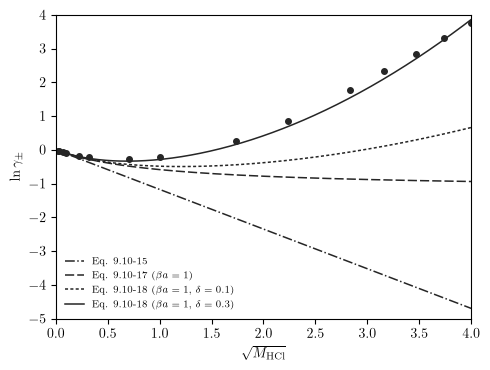

In [7]:
fig, ax = plt.subplots(figsize=(5.0, 3.8))
rootM = np.sqrt(M_hcl)
x = np.linspace(0, 4, 400)

# Line styles follow the 5e art: the fitted curve solid, the corrections dashed at
# two lengths, the limiting law dash-dot.
styles = [("-.",         "Eq. 9.10-15"),
          ((0, (6, 2)),  r"Eq. 9.10-17 ($\beta a = 1$)"),
          ((0, (2, 1.5)), r"Eq. 9.10-18 ($\beta a = 1$, $\delta = 0.1$)"),
          ("-",          r"Eq. 9.10-18 ($\beta a = 1$, $\delta = 0.3$)")]
for (ls, label), m in zip(styles, models.values()):
    ax.plot(x, m.ln_gamma_pm_from_I(x**2), ls=ls, color="0.15", lw=1.1, label=label)
ax.plot(rootM, np.log(g_hcl), "o", color="0.15", ms=4)

ax.set_xlabel(r"$\sqrt{M_{\rm HCl}}$"); ax.set_ylabel(r"$\ln\gamma_\pm$")
ax.set_xlim(0, 4); ax.set_ylim(-5, 4)
ax.legend(frameon=False, fontsize=7, loc="lower left")
fig.tight_layout()

wrote pdf/Fig_9.10-2.pdf


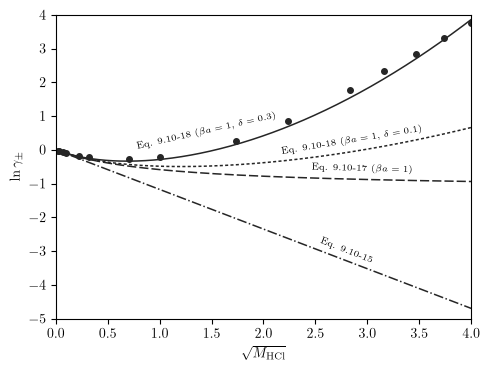

In [8]:
# --- Print art: Figure 9.10-2 ----------------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09f013.pdf
#
# Drawn to the printed figure's own conventions, checked against the 5e art
# (c09f013.jpg): ordinate ln(gamma_pm) from -5 to 4, abscissa sqrt(M_HCl) from 0
# to 4, four model curves labeled ON the curves rather than in a legend, data as
# filled circles.
#
# Labels are placed with thermo.charts.label_at, which puts the text at a given
# abscissa and rotates it to the curve's slope AS DRAWN, then lifted clear with a
# small offset so no curve strikes through its own label. Both the position and
# the lift are in DATA units, so the labels stay attached to their curves through
# a change of figure size -- what c09.md 14.9 asks for, and the reason none of the
# six existing ch9 figures lost a label when the chapter was re-sized.
from thermo.charts import label_at

figp, axp = plt.subplots(figsize=(5.0, 3.8))
axp.set_xlim(0, 4); axp.set_ylim(-5, 4)          # limits BEFORE label_at: it needs
                                                 # the transform to compute angles
curves = []
for (ls, label), m in zip(styles, models.values()):
    y = m.ln_gamma_pm_from_I(x**2)
    axp.plot(x, y, ls=ls, color="0.15", lw=1.1)
    curves.append((y, label))
axp.plot(rootM, np.log(g_hcl), "o", color="0.15", ms=4)

# The delta = 0.3 curve carries the data points, so its label is lifted further and
# moved inboard to clear them.
for (y, label), at, dy in zip(curves, (2.80, 2.95, 2.85, 1.45),
                                      (0.30, 0.32, 0.34, 0.62)):
    label_at(axp, x, y, label, along="x", value=at, size=6.5, offset=(0, dy))

axp.set_xlabel(r"$\sqrt{M_{\rm HCl}}$"); axp.set_ylabel(r"$\ln\gamma_\pm$")
figp.tight_layout()

import os
os.makedirs("pdf", exist_ok=True)
figp.savefig("pdf/Fig_9.10-2.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_9.10-2.pdf")

## Illustration 9.10-2 &mdash; sodium chloride, and fitting $\delta$

The second illustration takes the one remaining parameter and fits it. Its three
equations are the same three as above, written for a 1:1 salt at 25 &deg;C with
$\beta a = 1$:

$$\ln\gamma_\pm = -1.178\sqrt{I}
\qquad
\ln\gamma_\pm = \frac{-1.178\sqrt{I}}{1+\sqrt{I}}
\qquad
\ln\gamma_\pm = \frac{-1.178\sqrt{I}}{1+\sqrt{I}} + \delta I$$

and the answer printed for the third is $\delta = 0.137$.

**1.178 is not the number in Table 9.10-1.** The table gives $\alpha = 1.175$
at 25 &deg;C. The illustration's constant is 0.26% larger &mdash; small, and it changes
the fitted $\delta$ in the fourth decimal place, but a reader who follows the table
instead of the illustration will not reproduce the printed equations exactly. Both
values are computed below.

In [9]:
M_na, g_na = ILLUSTRATION_9_10_2_NACL.T

print("fitted delta for Eq. (3), which the illustration prints as 0.137:\n")
for source, a in [("the illustration's Eqs. (1)-(3)", 1.178),
                  ("Table 9.10-1 at 25 C          ", 1.175)]:
    base = DebyeHuckel("NaCl", beta_a=1, alpha=a)
    for wl, how in [(True, "fit in ln gamma"), (False, "fit in gamma   ")]:
        f = base.fit_delta(M_na, g_na, weight_log=wl)
        print(f"  alpha = {a}, {source}   {how}  ->  delta = {f.delta:.4f}"
              f"   rms(ln gamma) = {f.rms(M_na, g_na):.4f}")

fit = DebyeHuckel("NaCl", beta_a=1).fit_delta(M_na, g_na)
print("\nthe printed 0.137 comes back either way, and under either weighting --")
print("so the 1.178/1.175 discrepancy does not reach the answer.")
print(f"this notebook uses Table 9.10-1: delta = {fit.delta:.4f} -> {fit.delta:.3f}")

fitted delta for Eq. (3), which the illustration prints as 0.137:

  alpha = 1.178, the illustration's Eqs. (1)-(3)   fit in ln gamma  ->  delta = 0.1376   rms(ln gamma) = 0.0225
  alpha = 1.178, the illustration's Eqs. (1)-(3)   fit in gamma     ->  delta = 0.1371   rms(ln gamma) = 0.0226
  alpha = 1.175, Table 9.10-1 at 25 C             fit in ln gamma  ->  delta = 0.1371   rms(ln gamma) = 0.0219
  alpha = 1.175, Table 9.10-1 at 25 C             fit in gamma     ->  delta = 0.1367   rms(ln gamma) = 0.0219

the printed 0.137 comes back either way, and under either weighting --
so the 1.178/1.175 discrepancy does not reach the answer.
this notebook uses Table 9.10-1: delta = 0.1371 -> 0.137


In [10]:
eqs = {"Eq. (1), the limiting law":  DebyeHuckel("NaCl"),
       "Eq. (2), ba = 1":            DebyeHuckel("NaCl", beta_a=1),
       f"Eq. (3), delta = {fit.delta:.3f}": fit}

print(f"{'M':>6} {'gamma_pm':>9}" + "".join(f"{k:>26}" for k in eqs))
for M, g in zip(M_na, g_na):
    print(f"{M:6.2f} {g:9.3f}" + "".join(f"{m.gamma_pm(M):26.3f}" for m in eqs.values()))
print(f"\n{'rms in ln gamma_pm':>16}" + "".join(f"{m.rms(M_na, g_na):26.4f}"
                                                for m in eqs.values()))

     M  gamma_pm Eq. (1), the limiting law           Eq. (2), ba = 1    Eq. (3), delta = 0.137
  0.10     0.778                     0.690                     0.754                     0.764
  0.25     0.720                     0.556                     0.676                     0.699
  0.50     0.681                     0.436                     0.615                     0.658
  0.75     0.665                     0.361                     0.580                     0.642
  1.00     0.657                     0.309                     0.556                     0.637
  2.00     0.669                     0.190                     0.502                     0.661
  3.00     0.714                     0.131                     0.475                     0.716
  4.00     0.782                     0.095                     0.457                     0.791
  5.00     0.873                     0.072                     0.444                     0.881
  6.00     0.987                     0.056        

**The fitted equation is a factor of seventy better than the limiting law**,
and it buys that with one adjustable constant. But look at what $\delta$ is doing: it
is a linear term with no theory behind it, added to a square-root term that has a great
deal. It works because $\gamma_\pm$ for NaCl turns around and *rises* above about
1.5 molal, and nothing in Debye&ndash;H&uuml;ckel theory can turn around &mdash; the
limiting law and Eq. 9.10-17 both decrease forever.

**That is the honest reading of this section.** Eq. 9.10-15 is exact in a limit and
useless outside it; Eq. 9.10-18 is a correlation that happens to reduce to something
exact. The book says as much, and Eq. 9.10-19 (Pitzer) is where the chapter points for
anything better.

wrote pdf/Illustration_9.10-2.pdf


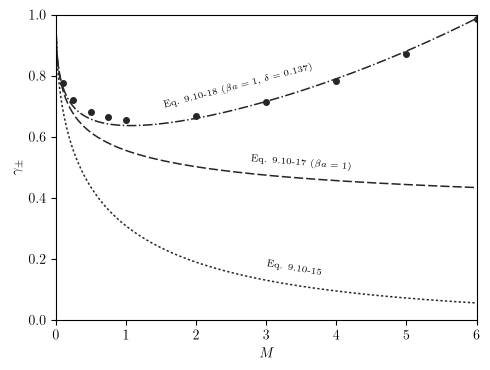

In [11]:
# --- Print art: Illustration 9.10-2 -----------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09uf003.pdf
#
# THE 5e ART FOR THIS FIGURE IS MISSING FROM THE FIGURE SET. c09uf001 and
# c09uf002 exist; c09uf003 does not, though the manuscript calls for it in an
# "Insert figure" slot and the printed page has it (5e p. 489). This is the second
# such gap in the chapter -- Fig. 9.7-3's placeholder and caption were also absent
# from the Word source (c09.md 3).
#
# Conventions taken from the printed page: ordinate gamma_pm (NOT ln gamma_pm --
# this figure and Fig. 9.10-2 differ, and each is drawn to its own printed
# convention), 0 to 1; abscissa M from 0 to 6; three curves labeled on the curves;
# data as filled circles. The printed art's line styles also differ from
# Fig. 9.10-2's for the same equations, and are followed here as printed.
#
# The points are NOT digitized from the printed art, which is misregistered
# against its own axes: every plotted point sits roughly 0.03 low against the
# illustration's own table, and the M = 6 point is missing from the plot
# altogether. The printed TABLE is the source ([[5e-art-not-metrological]]).
figu, axu = plt.subplots(figsize=(5.0, 3.8))
axu.set_xlim(0, 6); axu.set_ylim(0, 1)

Mx = np.linspace(0.0005, 6, 400)
labels = [r"Eq. 9.10-15",
          r"Eq. 9.10-17 ($\beta a = 1$)",
          rf"Eq. 9.10-18 ($\beta a = 1$, $\delta = {fit.delta:.3f}$)"]
for ls, m, label in zip(((0, (1.5, 1.5)), (0, (6, 2)), "-."), eqs.values(), labels):
    axu.plot(Mx, m.gamma_pm(Mx), ls=ls, color="0.15", lw=1.1)
axu.plot(M_na, g_na, "o", color="0.15", ms=4)

for m, label, at, dy in zip(eqs.values(), labels, (3.4, 3.5, 2.6), (0.055, 0.05, 0.075)):
    label_at(axu, Mx, m.gamma_pm(Mx), label, along="x", value=at, size=6.5,
             offset=(0, dy))

axu.set_xlabel(r"$M$"); axu.set_ylabel(r"$\gamma_\pm$")
figu.tight_layout()
figu.savefig("pdf/Illustration_9.10-2.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Illustration_9.10-2.pdf")

## What the mean is hiding

$\gamma_\pm$ is a geometric mean, Eq. 9.10-11: $\gamma_\pm^\nu = \gamma_+^{\nu_+}
\gamma_-^{\nu_-}$. For NaCl that is $\sqrt{\gamma_+\gamma_-}$, and the two factors
could be anything whose product is right. **No experiment can separate them**, which is
why the section defines the mean in the first place rather than treating it as a
convenience.

The same is true of the mean ionic molality, Eq. 9.10-12 &mdash; and there the
stoichiometry does show through.

In [12]:
print("mean ionic molality M_pm at M = 1 molal (Eqs. 9.10-12, 9.10-13):\n")
for name in ("NaCl", "CaCl2", "CuSO4"):
    e = ELECTROLYTES[name]
    print(f"  {name:6s} nu+={e.nu_plus} nu-={e.nu_minus} nu={e.nu}   "
          f"M_pm = {e.mean_ionic_molality(1.0):.4f} molal")
print("\n1:1 salts give M_pm = M; CaCl2 gives (1^1 . 2^2)^(1/3) M = 1.587 M,")
print("because a mole of it puts three moles of ions into solution, not two.")

mean ionic molality M_pm at M = 1 molal (Eqs. 9.10-12, 9.10-13):

  NaCl   nu+=1 nu-=1 nu=2   M_pm = 1.0000 molal
  CaCl2  nu+=1 nu-=2 nu=3   M_pm = 1.5874 molal
  CuSO4  nu+=1 nu-=1 nu=2   M_pm = 1.0000 molal

1:1 salts give M_pm = M; CaCl2 gives (1^1 . 2^2)^(1/3) M = 1.587 M,
because a mole of it puts three moles of ions into solution, not two.


**Your turn.**

1. Illustration 9.10-1 fixes $\beta a = 1$. The book says $a$ is "usually about
   4 &Aring;," which with $\beta = 0.3284$ makes $\beta a \approx 1.31$. Refit
   $\delta$ for HCl with $\beta a = 1.31$ and see whether the fit improves. Does the
   value of $\delta$ you need change a lot? What does that tell you about treating both
   as adjustable?
2. Try Eq. 9.10-18 on CuSO&#8324;, a 2:2 electrolyte, using data you find for it. The
   section warns that these equations get worse as the charges go up. By how much?
3. `DebyeHuckel` takes a temperature and reads Table 9.10-1. Plot $\gamma_\pm$ for
   0.1 molal NaCl from 0 to 100 &deg;C. Which way does it go, and is the size of the
   effect what you expected?
4. `ionic_strength` handles mixed electrolytes. What is $I$ for a solution 0.1 molal in
   NaCl *and* 0.05 molal in CaCl&#8322;? Which $\gamma_\pm$ does each salt get? (Careful:
   $I$ is the same for both salts, but $|z_+z_-|$ is not.)

## Related

- [`UNIFAC_benzene_TMP_example.ipynb`](UNIFAC_benzene_TMP_example.ipynb) &mdash; the
  models for *neutral* mixtures, which is everything else in the chapter.
- Chapter 15 reuses all of this: ionic strength in Sec. 15.2, and $\gamma_\pm$ in the
  ionization equilibria of Secs. 15.1 and 15.6.